# Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Instatiate a grid from a DEM raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [7]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

In [ ]:
# Heal the terrain to allow continuous flow
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# Flow Direction and Accumulation
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)
acc = grid.accumulation(fdir=fdir, dirmap=dirmap)

# Compute height above nearest drainage (HAND)

In [9]:
# Calculate Height Above Nearest Drainage for the whole grid
hand = grid.compute_hand(fdir=fdir, dem=dem, mask=(acc > 200))

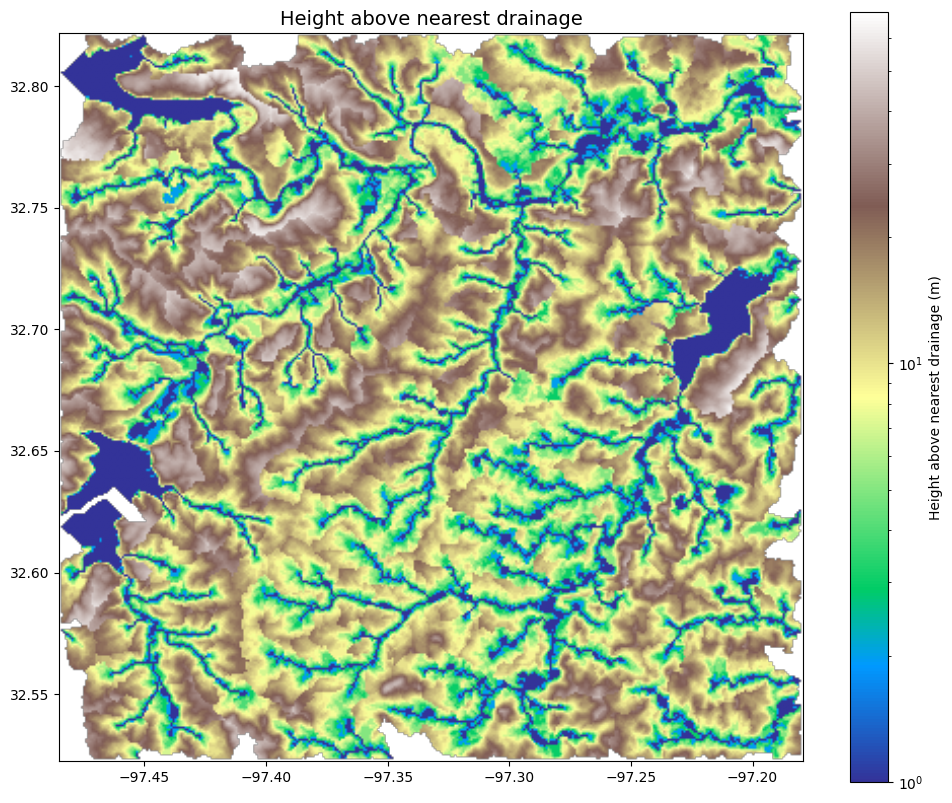

In [15]:
fig, ax = plt.subplots(figsize=(12,10))

# We use hand + 1 to avoid log(0) errors on the river lines
im = ax.imshow(hand + 1, zorder=1, cmap='terrain', interpolation='bilinear',
               extent=grid.extent,
               norm=colors.LogNorm(vmin=1, vmax=np.nanmax(hand)))

plt.colorbar(im, label='Height above nearest drainage (m)')
plt.title('Height above nearest drainage', size=14)
plt.show()

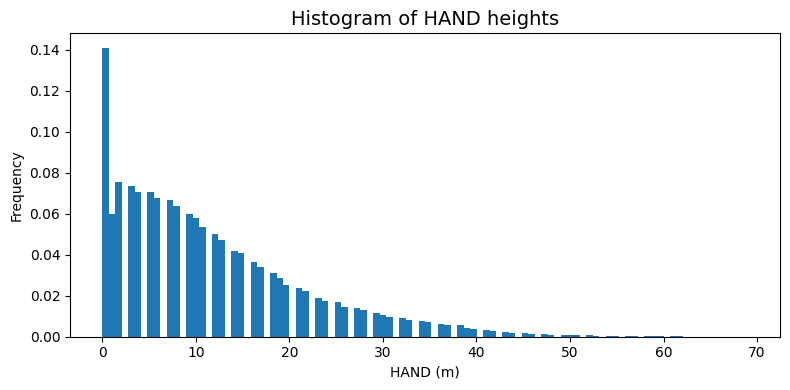

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

# Remove NaNs for the histogram calculation
hand_clean = hand[~np.isnan(hand)]
h = plt.hist(hand_clean, bins=100, density=True) # normed=True is deprecated, using density

plt.title('Histogram of HAND heights', size=14)
plt.ylabel('Frequency')
plt.xlabel('HAND (m)')
plt.tight_layout()
plt.show()

In [16]:
# Create 5 bins based on the distribution of data under 50m
_, bins = np.histogram(hand[~np.isnan(hand) & (hand < 50)], bins=5)

# Assign each pixel to a bin index
classes = np.digitize(hand, bins)

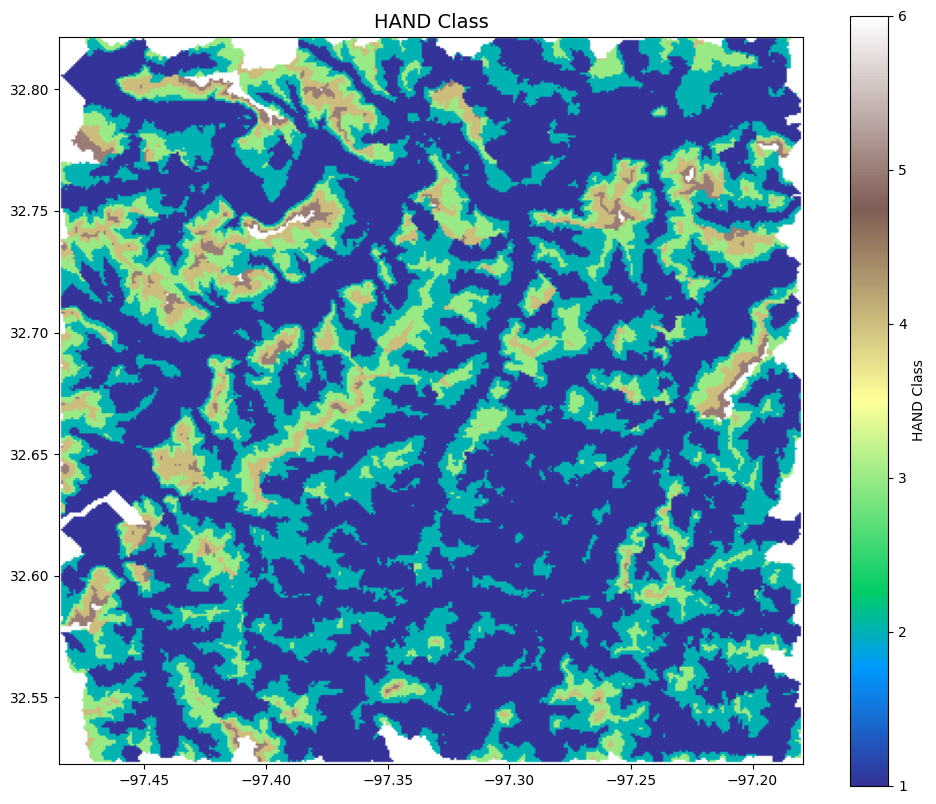

In [17]:
fig, ax = plt.subplots(figsize=(12,10))

# Plot the classified raster
im = ax.imshow(classes, zorder=1, cmap='terrain', extent=grid.extent)

plt.colorbar(im, label='HAND Class')
plt.title('HAND Class', size=14)
plt.show()